# E2E Usecase Metrics

Notebook nay chi ve 3 bieu do:

1. Latency cua tung use case
2. Diem cua tung use case
3. So step dung tren tong so step cua tung use case

In [15]:
# Uncomment neu moi truong chua co thu vien can thiet.
# !pip install pandas matplotlib

In [16]:
from __future__ import annotations

import json
import textwrap
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd


def find_artifact_dir() -> Path:
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        for candidate in (
            base / "artifacts" / "usecases",
            base / "testing-e2e" / "artifacts" / "usecases",
        ):
            if candidate.is_dir():
                return candidate
    raise FileNotFoundError("Cannot find testing-e2e/artifacts/usecases")


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.titlesize": 15,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "font.family": "DejaVu Sans",
    }
)


def chart_width(row_count: int) -> float:
    return max(12, min(22, row_count * 0.72 + 4))


def wrap_labels(values, width: int = 28):
    return ["\n".join(textwrap.wrap(str(value), width=width, break_long_words=False)) for value in values]


ARTIFACT_DIR = find_artifact_dir()
SUMMARY_PATH = ARTIFACT_DIR / "agent-evaluation-report.json"
ARTIFACT_DIR

WindowsPath('C:/Users/khai/k/V-Claw/testing-e2e/artifacts/usecases')

In [17]:
def load_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def parse_datetime(value):
    if not value:
        return None
    if isinstance(value, (int, float)):
        return datetime.fromtimestamp(value, tz=timezone.utc)
    text = str(value).strip()
    if not text:
        return None
    if text.endswith("Z"):
        text = text[:-1] + "+00:00"
    return datetime.fromisoformat(text)


def duration_ms_to_seconds(value) -> float | None:
    if isinstance(value, (int, float)):
        return round(value / 1000, 3)
    return None


def latency_seconds(run_report: dict) -> float | None:
    duration_ms = run_report.get("durationMs")
    if (seconds := duration_ms_to_seconds(duration_ms)) is not None:
        return seconds

    started_at = parse_datetime(run_report.get("startedAt"))
    finished_at = parse_datetime(run_report.get("finishedAt"))
    if started_at and finished_at:
        return round((finished_at - started_at).total_seconds(), 3)
    return None


def step_latency_values(conversation: list[dict]) -> list[float]:
    values = []
    for step in conversation:
        if not isinstance(step, dict):
            continue

        candidates = [
            step.get("durationMs"),
            step.get("latencyMs"),
        ]
        agent = step.get("agent")
        if isinstance(agent, dict):
            candidates.extend([agent.get("durationMs"), agent.get("latencyMs")])

        for value in candidates:
            seconds = duration_ms_to_seconds(value)
            if seconds is not None:
                values.append(seconds)
                break
        else:
            started_at = parse_datetime(step.get("startedAt") or step.get("started_at"))
            finished_at = parse_datetime(step.get("finishedAt") or step.get("finished_at"))
            if started_at and finished_at:
                values.append(round((finished_at - started_at).total_seconds(), 3))
    return values


def average_step_latency(run_report: dict, total_steps: int) -> tuple[float | None, float | None, int, str]:
    conversation = run_report.get("conversation") or []
    step_values = step_latency_values(conversation)
    if step_values:
        return round(sum(step_values) / len(step_values), 3), round(sum(step_values), 3), len(step_values), "step_duration"

    total_latency = latency_seconds(run_report)
    if total_latency is not None and total_steps:
        return round(total_latency / total_steps, 3), total_latency, total_steps, "run_duration_divided_by_steps"
    return None, None, 0, "missing"


if not SUMMARY_PATH.exists():
    raise FileNotFoundError(f"Cannot find evaluation report: {SUMMARY_PATH}")

summary = load_json(SUMMARY_PATH)
eval_reports = [
    item
    for item in summary.get("usecases", [])
    if isinstance(item, dict) and item.get("usecase")
]
if not eval_reports:
    raise ValueError(f"No evaluated use cases found in {SUMMARY_PATH}")

run_reports_by_usecase = {}
for path in sorted(ARTIFACT_DIR.glob("*.json")):
    if path.name == "agent-evaluation-report.json":
        continue
    run_report = load_json(path)
    if isinstance(run_report, dict):
        usecase = str(run_report.get("usecase") or path.stem)
        run_reports_by_usecase[usecase] = run_report

rows = []
for eval_report in eval_reports:
    usecase = str(eval_report["usecase"])
    eval_steps = [step for step in (eval_report.get("steps") or []) if isinstance(step, dict)]
    total_steps = len(eval_steps)
    correct_steps = sum(
        1
        for step in eval_steps
        if isinstance(step.get("llmEvaluation"), dict)
        and step["llmEvaluation"].get("passed") is True
    )
    score = eval_report.get("score")
    if score is None:
        score = correct_steps / total_steps if total_steps else None
    score_value = score if isinstance(score, (int, float)) else None
    score_steps = score_value * total_steps if score_value is not None else None
    missing_score_steps = max(total_steps - score_steps, 0) if score_steps is not None else None

    run_report = run_reports_by_usecase.get(usecase, {})
    avg_step_latency_s, total_latency_s, latency_step_count, latency_source = average_step_latency(
        run_report,
        total_steps,
    )

    rows.append(
        {
            "usecase": usecase,
            "status": eval_report.get("status"),
            "latency_s": avg_step_latency_s,
            "total_latency_s": total_latency_s,
            "latency_step_count": latency_step_count,
            "latency_source": latency_source,
            "score": score,
            "correct_steps": correct_steps,
            "total_steps": total_steps,
            "wrong_steps": max(total_steps - correct_steps, 0),
            "score_steps": score_steps,
            "missing_score_steps": missing_score_steps,
            "step_rate": correct_steps / total_steps if total_steps else None,
            "step_label": f"{correct_steps}/{total_steps}",
            "score_step_label": f"{score_value:.2f}" if score_value is not None else "N/A",
        }
    )

metrics = pd.DataFrame(rows).sort_values("usecase").reset_index(drop=True)
if metrics.empty:
    raise ValueError(f"No usecase run artifacts found in {ARTIFACT_DIR}")

## Overall summary

In [18]:
def format_number(value, digits: int = 3):
    if pd.isna(value):
        return "N/A"
    return f"{value:.{digits}f}"


def format_percent(value):
    if pd.isna(value):
        return "N/A"
    return f"{value:.2%}"


latency_rows = metrics[
    metrics["total_latency_s"].notna()
    & metrics["latency_step_count"].notna()
    & (metrics["latency_step_count"] > 0)
]
latency_step_total = int(latency_rows["latency_step_count"].sum())
avg_latency_per_step_s = (
    latency_rows["total_latency_s"].sum() / latency_step_total
    if latency_step_total
    else pd.NA
)

total_usecases = int(summary.get("total") or len(metrics))
total_steps = int(metrics["total_steps"].sum())
correct_steps = int(metrics["correct_steps"].sum())
wrong_steps = int(metrics["wrong_steps"].sum())
avg_score = (
    summary.get("totalScore") / total_usecases
    if isinstance(summary.get("totalScore"), (int, float)) and total_usecases
    else metrics["score"].dropna().mean()
)
overall_step_rate = correct_steps / total_steps if total_steps else pd.NA
passed_usecases = int(summary.get("passed") if isinstance(summary.get("passed"), (int, float)) else (metrics["status"] == "passed").sum())
failed_usecases = int(summary.get("failed") if isinstance(summary.get("failed"), (int, float)) else total_usecases - passed_usecases)

summary_table = pd.DataFrame(
    [
        {"metric": "Total use cases", "value": f"{total_usecases}"},
        {"metric": "Passed use cases", "value": f"{passed_usecases}"},
        {"metric": "Failed use cases", "value": f"{failed_usecases}"},
        {"metric": "Total steps", "value": f"{total_steps}"},
        {"metric": "Correct steps", "value": f"{correct_steps}"},
        {"metric": "Wrong steps", "value": f"{wrong_steps}"},
        {"metric": "Average latency per step", "value": f"{format_number(avg_latency_per_step_s, 3)}s"},
        {"metric": "Average score", "value": format_number(avg_score, 3)},
        {"metric": "Overall step pass rate", "value": format_percent(overall_step_rate)},
    ]
)

summary_table

,metric,value
0,Total use cases,26
1,Passed use cases,17
2,Failed use cases,9
3,Total steps,56
4,Correct steps,50
5,Wrong steps,6
6,Average latency per step,9.864s
7,Average score,0.743
8,Overall step pass rate,89.29%


## Average step latency by use case

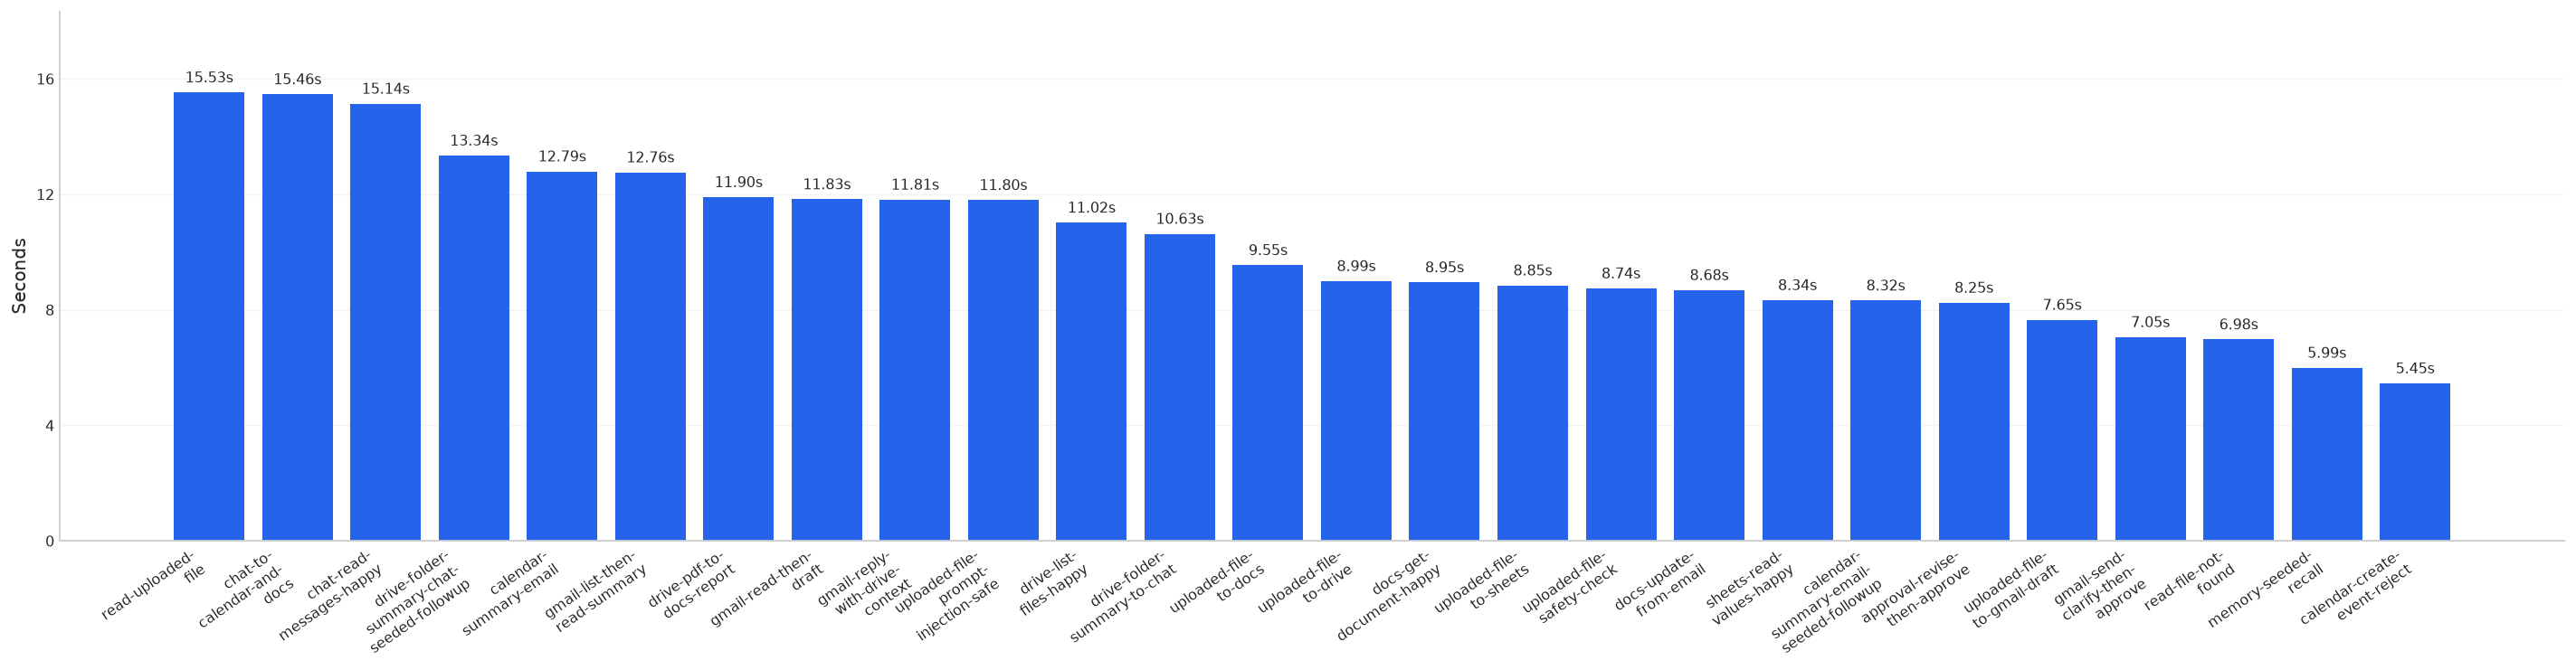

In [19]:
plot_df = metrics.sort_values("latency_s", ascending=False)
labels = wrap_labels(plot_df["usecase"], width=16)

fig, ax = plt.subplots(figsize=(chart_width(len(plot_df)), 5.8))
bars = ax.bar(labels, plot_df["latency_s"], color="#2563eb")

ax.set_xlabel("")
ax.set_ylabel("Seconds")
ax.bar_label(bars, labels=[f"{value:.2f}s" for value in plot_df["latency_s"]], padding=4, fontsize=9)
ax.set_ylim(0, max(plot_df["latency_s"].max() * 1.18, 1))
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
ax.tick_params(axis="x", rotation=35)
for tick in ax.get_xticklabels():
    tick.set_ha("right")
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## Score by use case

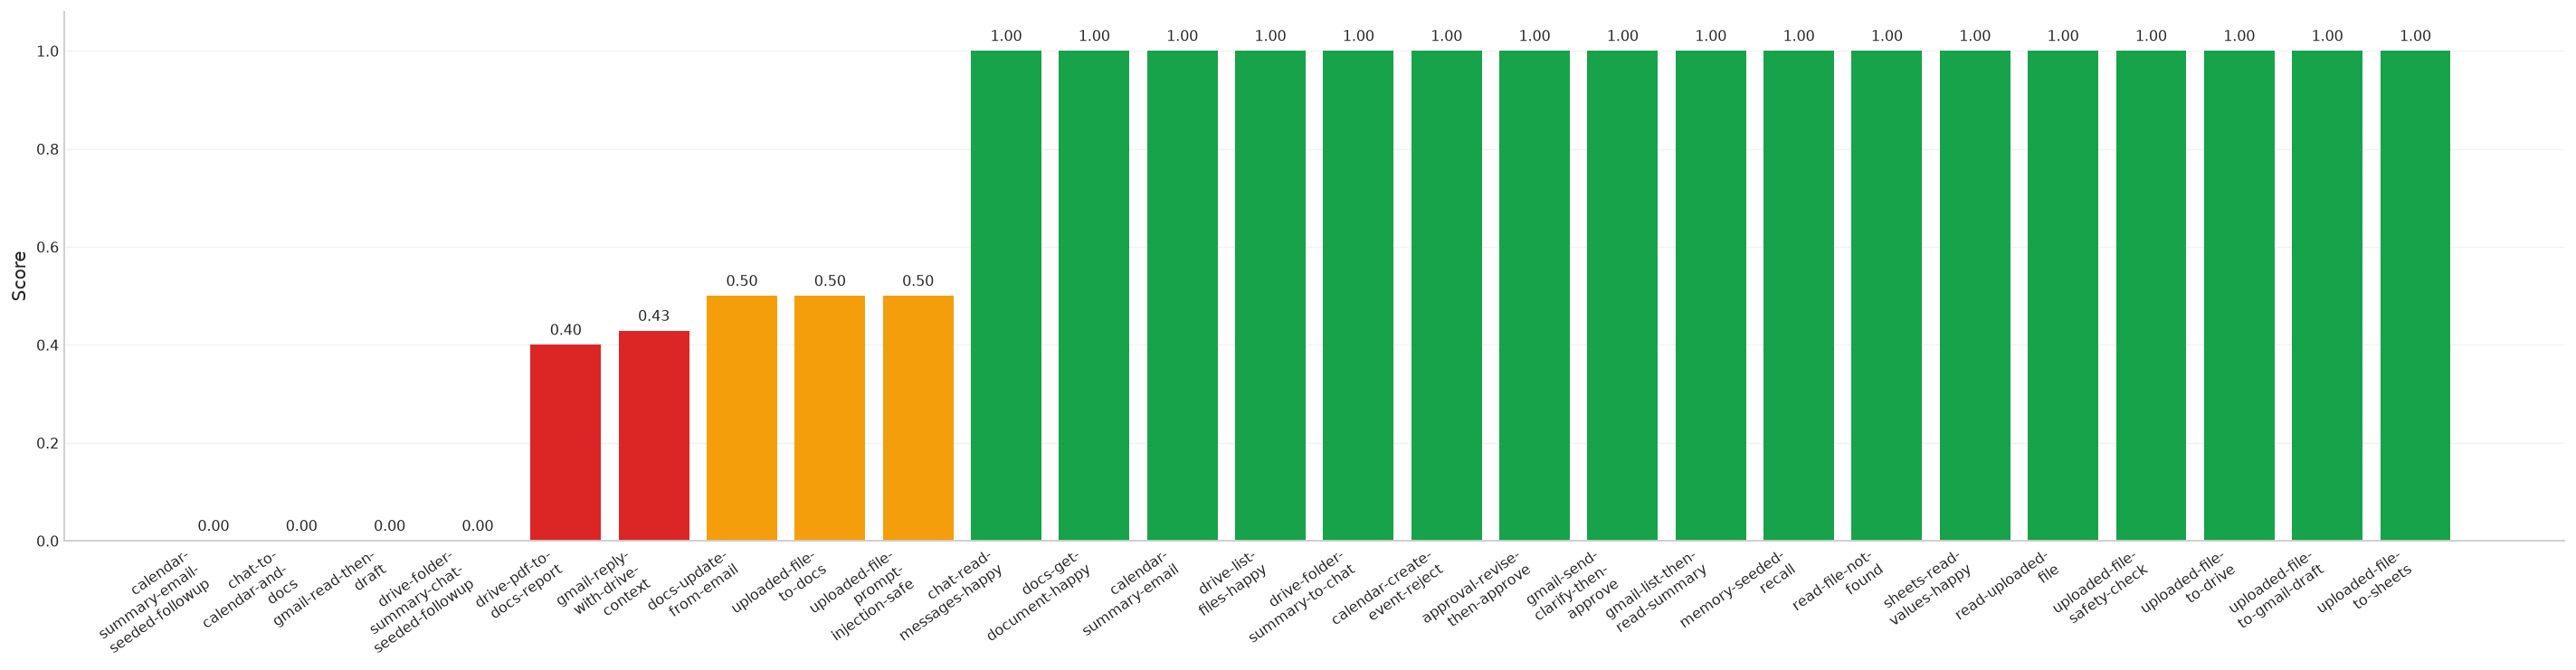

In [20]:
plot_df = metrics.sort_values("score", ascending=True)
labels = wrap_labels(plot_df["usecase"], width=16)
colors = ["#dc2626" if value < 0.5 else "#f59e0b" if value < 0.8 else "#16a34a" for value in plot_df["score"]]

fig, ax = plt.subplots(figsize=(chart_width(len(plot_df)), 5.8))
bars = ax.bar(labels, plot_df["score"], color=colors)

ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.08)
ax.bar_label(bars, labels=[f"{value:.2f}" for value in plot_df["score"]], padding=4, fontsize=9)
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
ax.tick_params(axis="x", rotation=35)
for tick in ax.get_xticklabels():
    tick.set_ha("right")
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## Score-weighted steps by use case

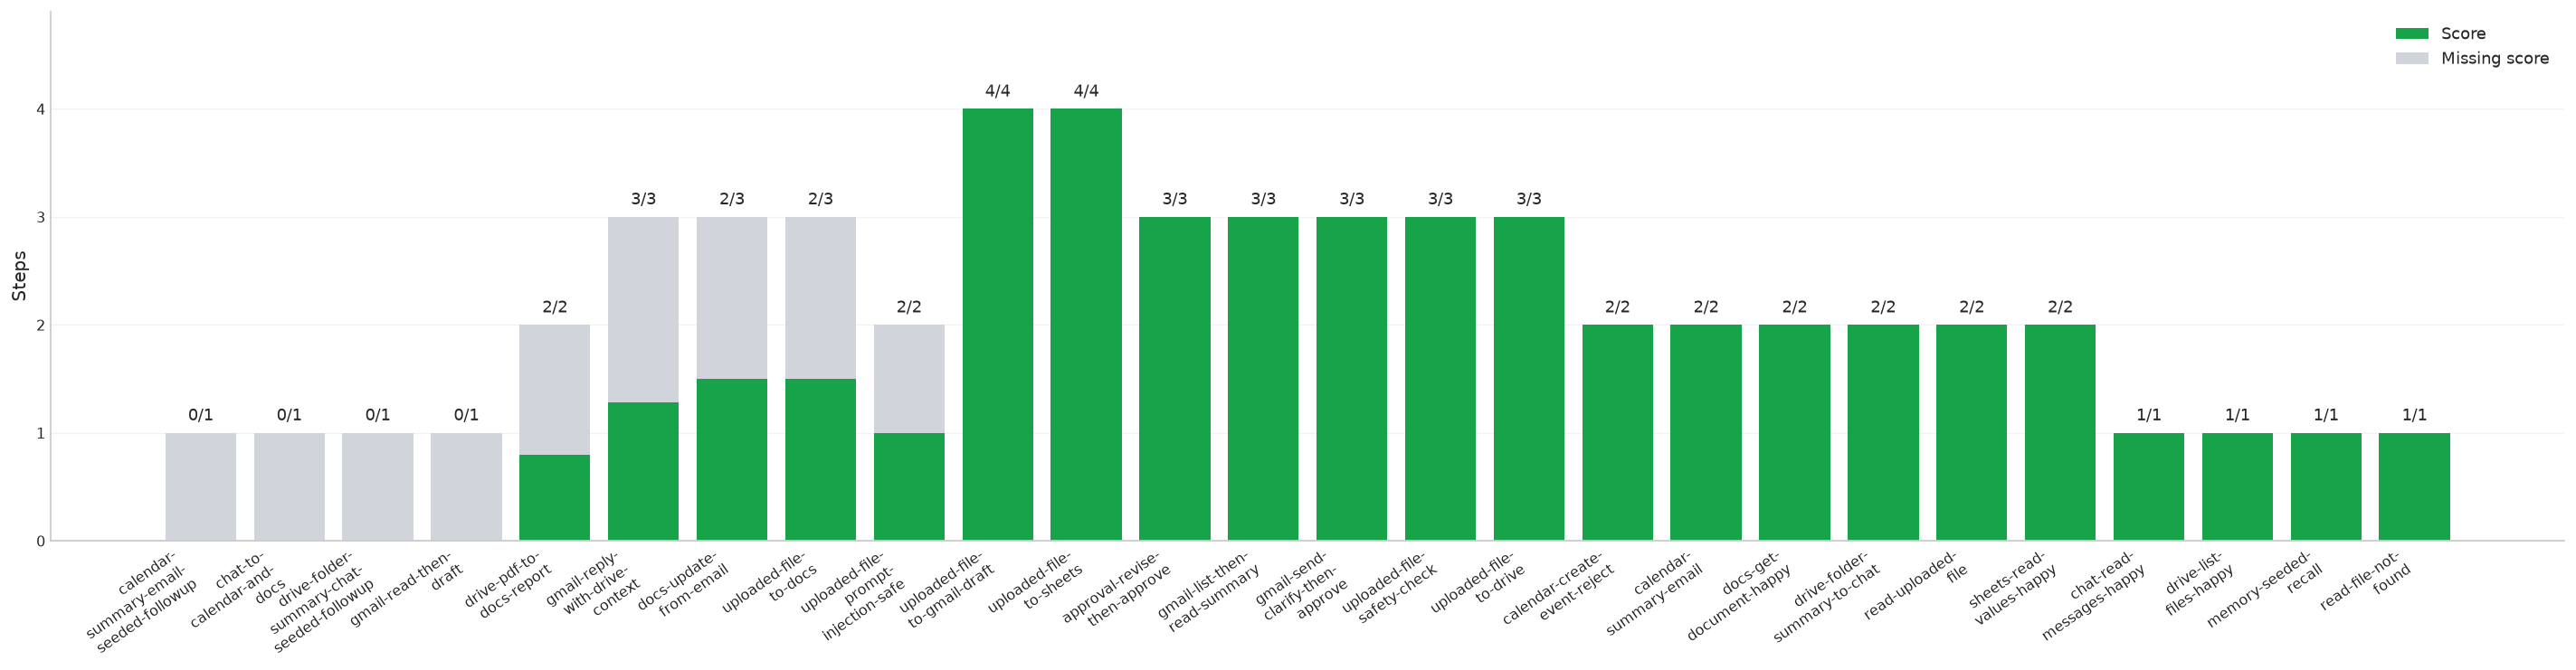

In [21]:
plot_df = metrics.sort_values(["score", "total_steps"], ascending=[True, False])
labels = wrap_labels(plot_df["usecase"], width=16)

fig, ax = plt.subplots(figsize=(chart_width(len(plot_df)), 5.8))
score_bars = ax.bar(labels, plot_df["score_steps"], color="#16a34a", label="Score")
ax.bar(
    labels,
    plot_df["missing_score_steps"],
    bottom=plot_df["score_steps"],
    color="#d1d5db",
    label="Missing score",
)

for index, (total, label) in enumerate(zip(plot_df["total_steps"], plot_df["step_label"])):
    ax.text(
        index,
        total + 0.08,
        label,
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_xlabel("")
ax.set_ylabel("Steps")
ax.set_ylim(0, max(plot_df["total_steps"].max() + 0.9, 1))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.tick_params(axis="x", rotation=35)
for tick in ax.get_xticklabels():
    tick.set_ha("right")
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)
ax.legend(loc="upper right", frameon=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()